# Exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from festival_analysis.analysis_utils import query_db

plt.style.use('ggplot')

In [2]:
%matplotlib inline

## Festivals

In [3]:
query_festivals = '''
SELECT 
  CAST(festival_id AS VARCHAR) AS festival_id,
  name,
  size_band,
  sb.description AS size_band_description
FROM festivals f
JOIN size_bands sb ON f.size_band = sb.label
'''

df_festivals = query_db(query_festivals, index='festival_id')
df_festivals.info()
df_festivals.head()

<class 'pandas.core.frame.DataFrame'>
Index: 134 entries, 8868442761932147185 to 4337727016300241434
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   name                   134 non-null    object
 1   size_band              134 non-null    object
 2   size_band_description  134 non-null    object
dtypes: object(3)
memory usage: 4.2+ KB


,name,size_band,size_band_description
festival_id,,,
8868442761932147185,Lentekabinet,2 - S,"2,500 – 10,000"
3770262822180965878,Stone Techno,3 - M,"10,000 – 30,000"
3545183190061113930,XRDS,2 - S,"2,500 – 10,000"
7308788476028549761,memòri,1 - XS,"under 2,500"
41474036776617358,RIT/MO,1 - XS,"under 2,500"


In [4]:
df_festivals[['size_band', 'size_band_description']].drop_duplicates().sort_values('size_band')

,size_band,size_band_description
festival_id,,
7308788476028549761,1 - XS,"under 2,500"
8868442761932147185,2 - S,"2,500 – 10,000"
3770262822180965878,3 - M,"10,000 – 30,000"
584339127840213479,4 - L,"30,000 – 75,000"
6952660926306554150,5 - XL,"75,000+"


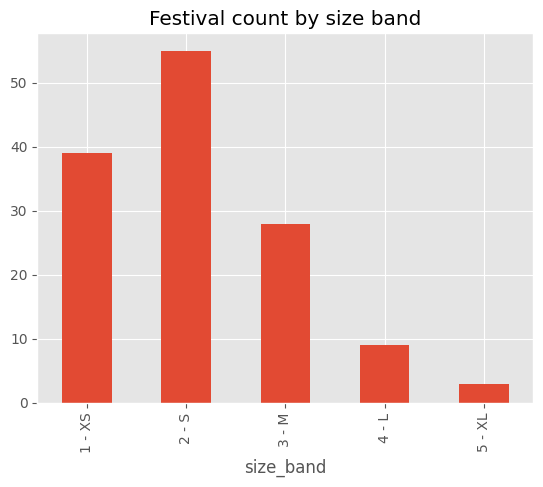

In [5]:
df_festivals.groupby('size_band').size().plot(kind='bar', title="Festival count by size band")
plt.show()

Most festivals in the dataset are on the smaller side: up to 10k. Only a few XL ones (75k+).

## Festival editions

In [6]:
query_festival_instances = '''
SELECT
  primary_event_id,
  f.name||'-'||fe.edition_year AS edition_name,
  CAST(fe.festival_id AS VARCHAR) AS festival_id,
  f.name AS festival_name,
  fe.edition_year,
  f.size_band,
  fe.start_date,
  fe.end_date,
  c.continent AS location_continent,
  fe.location_country,
  fe.location_city
FROM
  festivals f
  LEFT JOIN editions fe USING(festival_id)
  LEFT JOIN countries c ON fe.location_country = c.country
'''

df_festival_editions = query_db(query_festival_instances, index='primary_event_id')
df_festival_editions.info()
df_festival_editions.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1020 entries, 679606 to None
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   edition_name        1018 non-null   object        
 1   festival_id         1018 non-null   object        
 2   festival_name       1020 non-null   object        
 3   edition_year        1018 non-null   Int32         
 4   size_band           1020 non-null   object        
 5   start_date          1018 non-null   datetime64[us]
 6   end_date            1018 non-null   datetime64[us]
 7   location_continent  1017 non-null   object        
 8   location_country    1018 non-null   object        
 9   location_city       1018 non-null   object        
dtypes: Int32(1), datetime64[us](2), object(7)
memory usage: 84.7+ KB


,edition_name,festival_id,festival_name,edition_year,size_band,start_date,end_date,location_continent,location_country,location_city
primary_event_id,,,,,,,,,,
679606,AVA-2015,4764419292083662650,AVA,2015,3 - M,2015-05-30,2015-05-30,Europe,GB,Belfast
1618490,AVA-2023,4764419292083662650,AVA,2023,3 - M,2023-02-24,2023-12-31,Europe,GB,Belfast
1382287,Accidental Meetings-2020,1336484889209428545,Accidental Meetings,2020,1 - XS,2020-02-07,2020-12-05,Europe,GB,Brighton
1468214,Accidental Meetings-2021,1336484889209428545,Accidental Meetings,2021,1 - XS,2021-07-21,2021-12-11,Europe,GB,London
1400733,Animal Crossing-2020,6444672821443970373,Animal Crossing,2020,2 - S,2020-03-28,2020-05-24,Europe,GB,Manchester


In [7]:
# Save top countries for filtering later
n_countries = 10
top_n_countries = df_festival_editions.groupby('location_country').size().sort_values(ascending=False).index[:n_countries]

### Geo-based

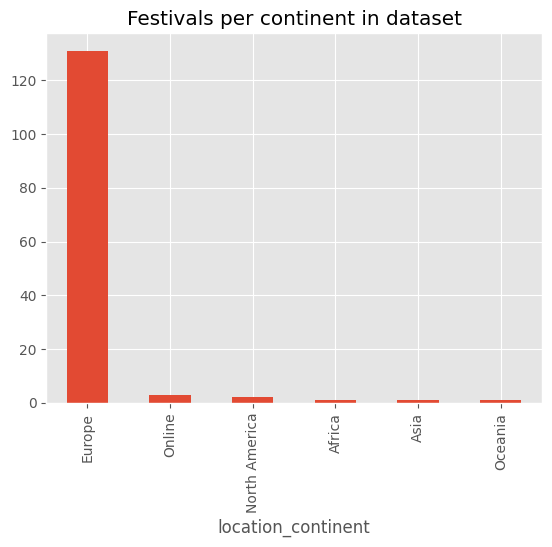

In [8]:
festivals_per_continent = df_festival_editions.groupby('location_continent')['festival_id'].nunique().rename('festivals').sort_values(ascending=False)
festivals_per_continent.plot(kind='bar', title='Festivals per continent in dataset')
plt.show()

Overwhelmingly Europe-based dataset.

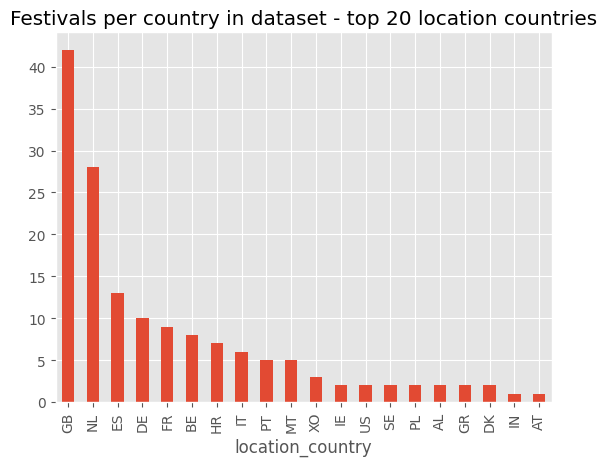

In [9]:
festivals_per_country = df_festival_editions.groupby('location_country')['festival_id'].nunique().rename('festivals').sort_values(ascending=False)
festivals_per_country.head(20).plot(kind='bar', title='Festivals per country in dataset - top 20 location countries')
plt.show()

Western Europe is leading with the UK and Netherlands dominating. Croatia is a classic festival destination for Western Europeans. 

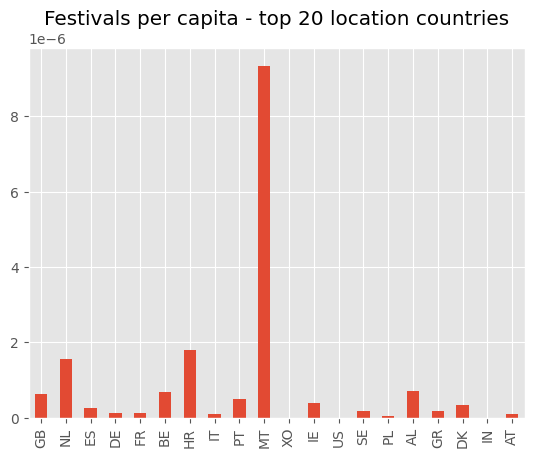

In [10]:
country_populations = query_db('SELECT country, population FROM countries', index='country')
festivals_per_country = festivals_per_country.to_frame().merge(
    country_populations, left_index=True, right_index=True
)
festivals_per_country['festivals_per_capita'] = festivals_per_country['festivals'] / festivals_per_country['population']
festivals_per_country['festivals_per_capita'].head(20).plot(kind='bar', title='Festivals per capita - top 20 location countries')
plt.show()

Netherlands, Croatia and particularly Malta have very outsize festival counts per capita.

### Time-based

In [11]:
df_festivals['years'] = df_festival_editions.groupby('festival_id')['edition_year'].nunique()
df_festival_editions['month'] = df_festival_editions['start_date'].dt.month
df_festival_editions['dayofyear'] = df_festival_editions['start_date'].dt.dayofyear

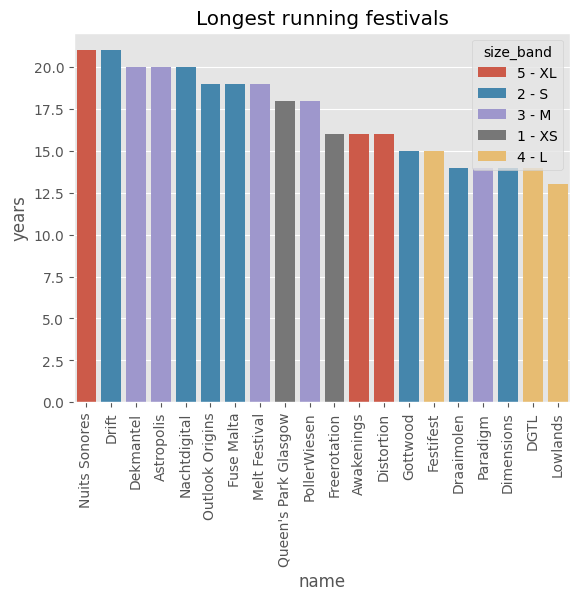

In [12]:
years_by_festival_and_size = df_festivals.groupby(['name', 'size_band'])['years'].max().reset_index().sort_values('years', ascending=False).head(20)
sns.barplot(data=years_by_festival_and_size, x='name', y='years', hue='size_band')
plt.xticks(rotation=90)
plt.title('Longest running festivals')
plt.show()

Some interesting ones in here that I hadn't heard of.

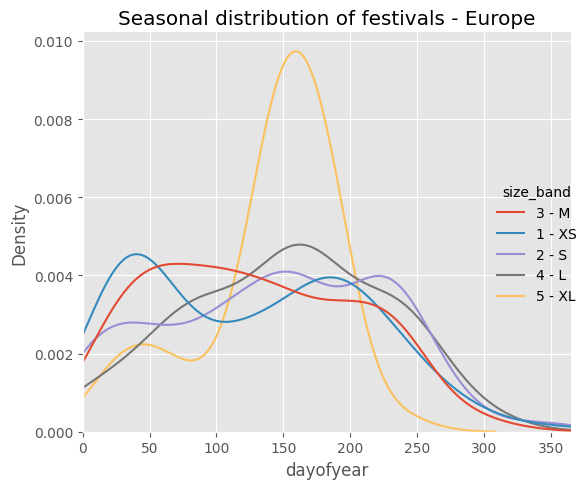

In [13]:
sns.displot(df_festival_editions.query('location_continent == "Europe"'), x='dayofyear', hue='size_band', kind='kde', common_norm=False)
plt.gca().set_xlim(0, 365)
plt.title('Seasonal distribution of festivals - Europe')
plt.tight_layout()
plt.show()

Interesting that the XL festivals pretty much all happen around the solstice while others are much more distributed (until October when nothing happens).

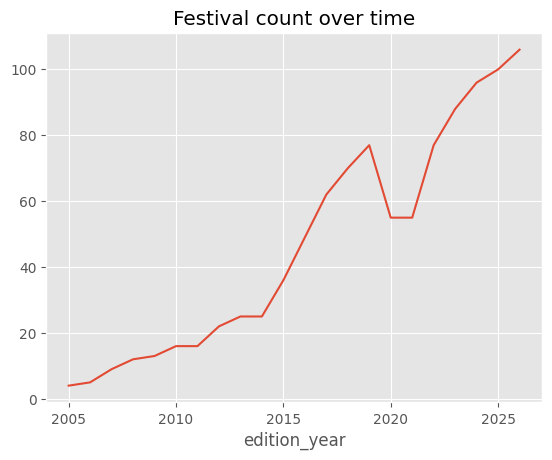

In [14]:
df_festival_editions.groupby('edition_year').size().plot(title='Festival count over time')
plt.show()

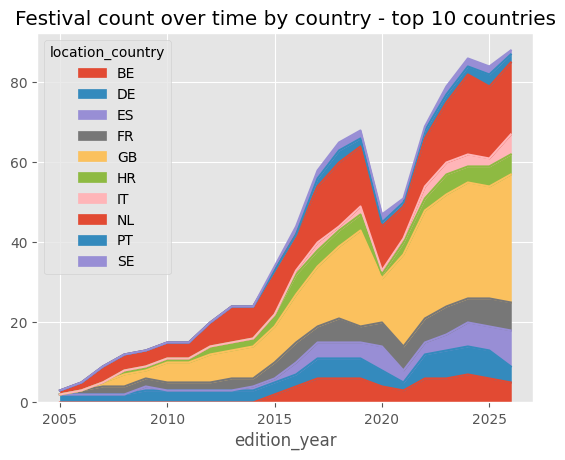

In [15]:
df_festival_editions.query('location_country.isin(@top_n_countries)').groupby(['edition_year', 'location_country']).size().unstack('location_country').plot(kind='area', title=f'Festival count over time by country - top {n_countries} countries')
plt.show()

Belgium coming in as a strong late entry.

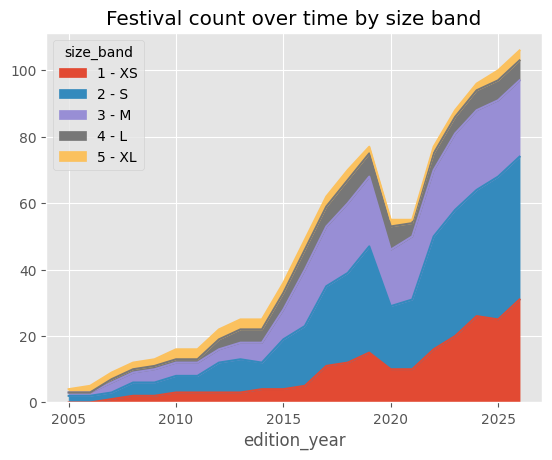

In [16]:
df_festival_editions.groupby(['edition_year', 'size_band']).size().unstack('size_band').plot(kind='area', title='Festival count over time by size band')
plt.show()

Most growth has been in XS to M festival sizes, not many new huge ones over the years.

## Artists

In [17]:
query_artists = '''
SELECT
  artist_id,
  display_name,
  normalized_name,
  country,
  instagram_url,
  soundcloud_url,
  twitter_url,
  ra_status
FROM
  artists
'''

df_artists = query_db(query_artists, index='artist_id')
df_artists.info()
df_artists.head()

<class 'pandas.core.frame.DataFrame'>
Index: 13370 entries, 6091290227018595420 to 284074544580349533
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   display_name     13370 non-null  object
 1   normalized_name  13370 non-null  object
 2   country          12702 non-null  object
 3   instagram_url    6109 non-null   object
 4   soundcloud_url   9678 non-null   object
 5   twitter_url      3548 non-null   object
 6   ra_status        12897 non-null  object
dtypes: object(7)
memory usage: 835.6+ KB


,display_name,normalized_name,country,instagram_url,soundcloud_url,twitter_url,ra_status
artist_id,,,,,,,
6091290227018595420,Mark du Mosch,mark du mosch,NL,None,https://www.soundcloud.com/mark-du-mosch,None,REGIONAL
2697707424209543123,Vakula,vakula,UA,None,https://www.soundcloud.com/vakula,None,REGIONAL
54795653360061378,Dekmantel Soundsystem,dekmantel soundsystem,NL,None,None,None,TOP1000
244283973373672122,FunkinEven,funkineven,GB,None,https://www.soundcloud.com/funkineven,None,TOP1000
7414316904780250463,Kyle Hall,kyle hall,US,https://www.instagram.com/kmfh313,https://www.soundcloud.com/kmfh,https://www.twitter.com/kylehalldetroit,TOP1000


13k unique artists across all festivals. 6k have instagram linked, 10k have soundcloud linked, only 3.5k have twitter linked.

In [18]:
df_artists.groupby('ra_status', dropna=False).size()

ra_status
DENIED          2
REGIONAL    11945
TOP1000       950
NaN           473
dtype: int64

We have 95% of the RA-marked top 1000 DJs in our festivals dataset. 500 DJs have no `ra_status` assigned. 2 are `DENIED`.

In [19]:
df_artists.query('ra_status == "DENIED"')

,display_name,normalized_name,country,instagram_url,soundcloud_url,twitter_url,ra_status
artist_id,,,,,,,
7529968439917853634,szoliver,szoliver,None,https://www.instagram.com/szoliver,https://www.soundcloud.com/szoliver,None,DENIED
7520787797986575097,JAY,jay,GB,https://www.instagram.com/drumsofjay,https://www.soundcloud.com/drumsofjay,None,DENIED


Wonder what DENIED means :(

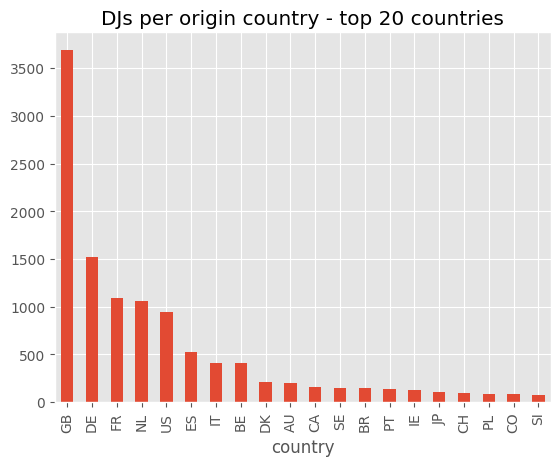

In [20]:
djs_per_country = df_artists.groupby('country').size().rename('djs').sort_values(ascending=False)
djs_per_country[:20].plot(kind='bar', title='DJs per origin country - top 20 countries')
plt.show()

UK absolutely dominating on festival DJ exports, more than double any other country. US has high representation considering the lack of US festivals in the dataset, to be expected given musical contributions.

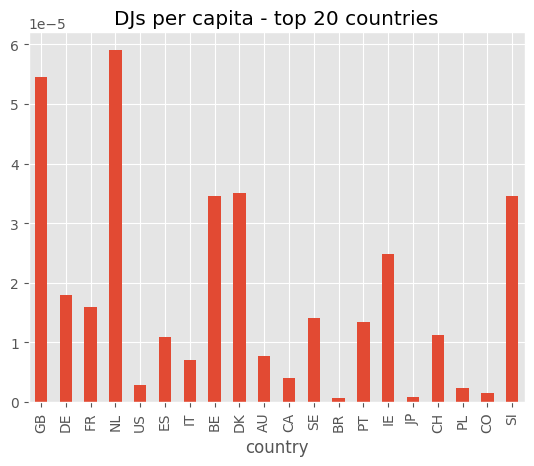

In [21]:
djs_per_country = djs_per_country.to_frame().merge(
    country_populations, left_index=True, right_index=True
)
djs_per_country['djs_per_capita'] = djs_per_country['djs'] / djs_per_country['population']
djs_per_country['djs_per_capita'][:20].plot(kind='bar', title='DJs per capita - top 20 countries')
plt.show()

Again, UK and the Netherlands dominate on DJs per capita, with Belgium, Denmark, Slovenia and Ireland tailing.

In [22]:
query_artist_stats = '''
SELECT
  artist_id,
  display_name,
  country,
  ra_status,
  festivals_count,
  festival_bookings_count,
  first_year,
  last_year,
  years_span
FROM
  artist_stats
'''

df_artist_stats = query_db(query_artist_stats, index='artist_id')
df_artist_stats.info()
df_artist_stats.head()
  

<class 'pandas.core.frame.DataFrame'>
Index: 13267 entries, 2873385812439654847 to 7318143674214472939
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   display_name             13267 non-null  object
 1   country                  12602 non-null  object
 2   ra_status                12797 non-null  object
 3   festivals_count          13267 non-null  int64 
 4   festival_bookings_count  13267 non-null  int64 
 5   first_year               13267 non-null  int32 
 6   last_year                13267 non-null  int32 
 7   years_span               13267 non-null  int32 
dtypes: int32(3), int64(2), object(3)
memory usage: 777.4+ KB


,display_name,country,ra_status,festivals_count,festival_bookings_count,first_year,last_year,years_span
artist_id,,,,,,,,
2873385812439654847,Cromby,IE,TOP1000,8,17,2015,2026,11
7065030523352562050,Timmy Stewart,GB,REGIONAL,1,9,2015,2024,9
5907916968379152333,Hammer,GB,REGIONAL,5,12,2015,2024,9
7812633737861075522,Dave Clarke,GB,TOP1000,12,24,2006,2025,19
4978356095577778632,Shanti Celeste,GB,TOP1000,48,112,2015,2026,11


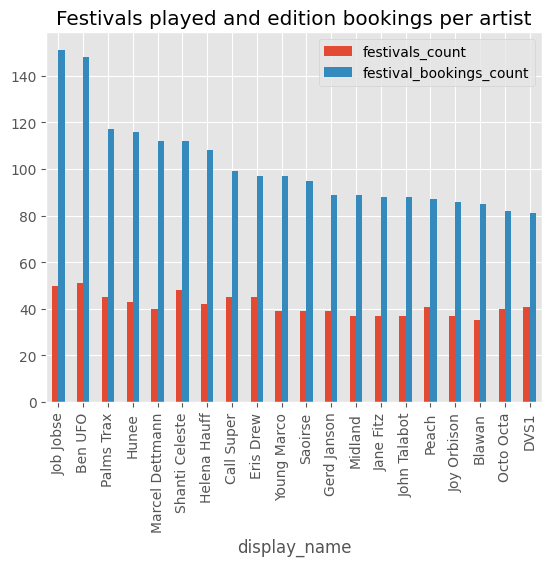

In [23]:
bookings_per_artist = df_artist_stats.groupby('display_name')[['festivals_count', 'festival_bookings_count']].sum().sort_values('festival_bookings_count', ascending=False)
bookings_per_artist[:20].plot(kind='bar', title='Festivals played and edition bookings per artist')
plt.show()

## Lineups

In [24]:
query_lineups = '''
SELECT
  entry_id,
  festival_id,
  festival_id||'-'||edition_year AS edition_id,
  festival_name,
  size_band,
  edition_year,
  location_country,
  artist_id,
  display_name,
  artist_country,
  ra_status
FROM
  edition_lineups
-- Look onwards from 2015 without lockdown years
WHERE 
  edition_year >= 2015 
  AND edition_year NOT IN (2020, 2021)
'''

df_lineups = query_db(query_lineups, index='entry_id')
df_lineups.info()
df_lineups.head()

<class 'pandas.core.frame.DataFrame'>
Index: 49409 entries, 2595357249563868203 to 3504520056035378041
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   festival_id       49409 non-null  int64 
 1   edition_id        49409 non-null  object
 2   festival_name     49409 non-null  object
 3   size_band         49409 non-null  object
 4   edition_year      49409 non-null  int32 
 5   location_country  49409 non-null  object
 6   artist_id         49409 non-null  int64 
 7   display_name      49409 non-null  object
 8   artist_country    47658 non-null  object
 9   ra_status         48445 non-null  object
dtypes: int32(1), int64(2), object(7)
memory usage: 4.0+ MB


,festival_id,edition_id,festival_name,size_band,edition_year,location_country,artist_id,display_name,artist_country,ra_status
entry_id,,,,,,,,,,
2595357249563868203,1336484889209428545,1336484889209428545-2024,Accidental Meetings,1 - XS,2024,GB,4380596148803238082,marjai,GB,REGIONAL
9027170930573183792,6444672821443970373,6444672821443970373-2024,Animal Crossing,2 - S,2024,GB,798404442173256865,Môtus (UK),GB,REGIONAL
8374729915735115853,3474193437919919623,3474193437919919623-2019,Eletrico,2 - S,2019,PT,5285086573553548460,Apollonia,FR,TOP1000
3766624900797988704,1933254102662224256,1933254102662224256-2025,Sandbox,2 - S,2025,AU,7120040059916815262,mara (AU),AU,REGIONAL
6760558579921007914,1595638758833657518,1595638758833657518-2024,Astropolis,3 - M,2024,FR,4698219912509889788,Manu Le Malin,FR,REGIONAL


In [25]:
n_artists = 20
top_n_artists = df_artist_stats.groupby('artist_id')['festival_bookings_count'].sum().sort_values(ascending=False)[:n_artists].index

In [26]:
n_artist_countries = 20
top_n_artist_countries = df_artist_stats.groupby('country').size().sort_values(ascending=False)[:n_artists].index

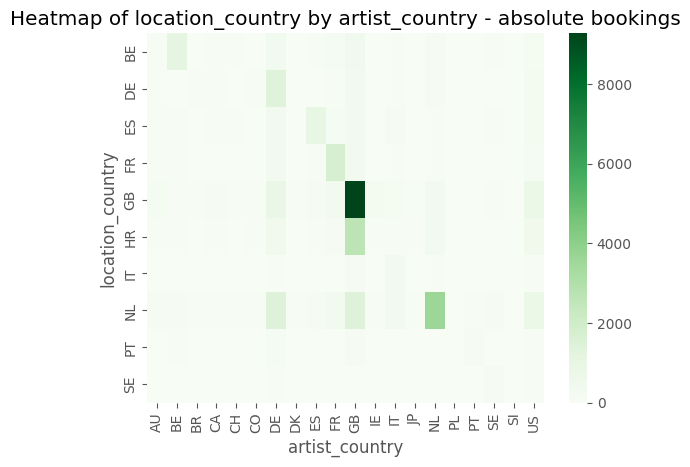

In [27]:
df_lineups_top_n_countries = df_lineups[
    (df_lineups['artist_country'].isin(top_n_artist_countries))
    & (df_lineups['location_country'].isin(top_n_countries))
]

sns.heatmap(df_lineups_top_n_countries.groupby(['location_country', 'artist_country']).size().unstack().fillna(0), cmap="Greens")
plt.title('Heatmap of location_country by artist_country - absolute bookings')
plt.show()

UK and NL show bright due to outsize number of festivals (and therefore bookings) in these countries, but you can see some interesting patterns:
- Croatian festivals book a large amount of UK artists.
- German artists tend to pop up in several festival countries.

Let's normalize by possible bookings for a clearer picture.

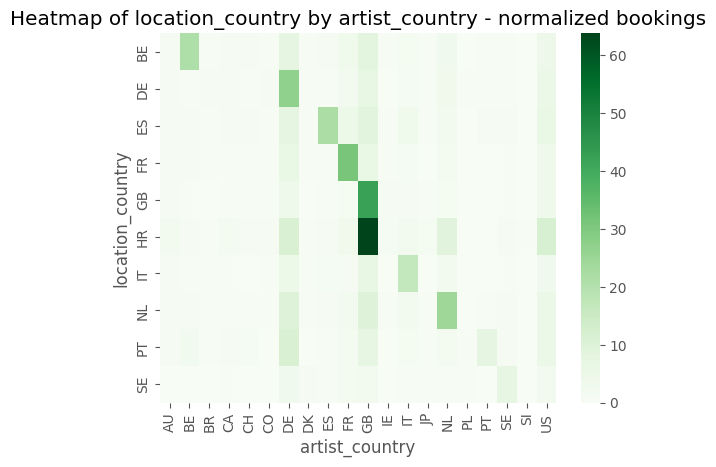

In [28]:
possible_bookings_per_country = df_lineups.groupby('location_country')['edition_id'].nunique().rename('count_editions')
df_lineups_top_n_countries = df_lineups_top_n_countries.merge(
    possible_bookings_per_country,
    how='left', left_on='location_country', right_index=True
)
country_bookings_heatmap = df_lineups_top_n_countries.groupby(['location_country', 'artist_country', 'count_editions']).size().rename('bookings').reset_index('count_editions')
country_bookings_heatmap['bookings_per_edition'] = country_bookings_heatmap['bookings'] / country_bookings_heatmap['count_editions']
sns.heatmap(country_bookings_heatmap['bookings_per_edition'].unstack().fillna(0), cmap="Greens")
plt.title('Heatmap of location_country by artist_country - normalized bookings')
plt.show()

Similar picture but a little clearer now:
- Festivals tend to mostly book home-grown DJs
- Croatia books a completely outsize number of UK DJs, a consequence of British-run festivals held in Croatia
- German, British and US DJs tend to play festivals across a wide distribution of countries

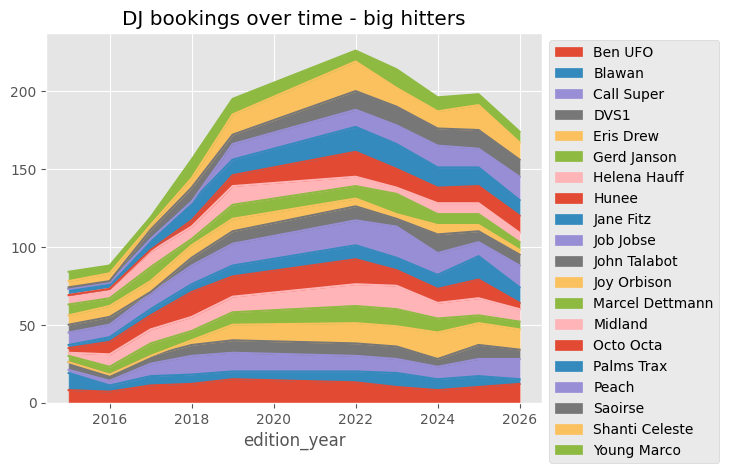

In [29]:
df_lineups_top_n_artists = df_lineups[df_lineups['artist_id'].isin(top_n_artists)]
artist_bookings_per_year = df_lineups_top_n_artists.groupby(['display_name', 'edition_year'])['edition_id'].nunique().rename('bookings')
artist_bookings_per_year.unstack('display_name').plot(kind='area', title='DJ bookings over time - big hitters')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

CAUTION - Legend is inverse to stack order

Booking count grows with number of festivals, let's normalize to see who's growing and falling.

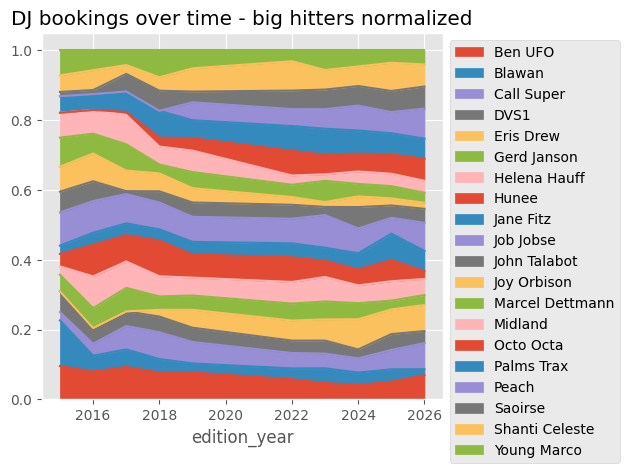

In [30]:
bookings_per_year = artist_bookings_per_year.to_frame().groupby('edition_year')['bookings'].sum()
artist_bookings_per_year_norm = artist_bookings_per_year.unstack('display_name').div(bookings_per_year, axis=0)
artist_bookings_per_year_norm.plot(kind='area', title='DJ bookings over time - big hitters normalized')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()

CAUTION - Legend is inverse to stack order

Unbelievably static over the last 10 years! 
- Eris Drew, Octo Octa, Peach and Saiorse are the only newcomers. 
- Gerd Janson, Hunee and Joy O winding down a little.